# Classificação — Previsão de Cancelamento de Clientes (Churn)

**Disciplina:** Machine Learning — Modelos de Classificação
**Aluno:** Eduardo Vitor Oliveira
**Professor:** Ricardo
**Data:** 18/09/2026
**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — Kaggle (IBM Sample Data Sets)

### Objetivo
Construir um modelo de **classificação binária** para prever se um cliente de uma empresa de telecomunicações vai **cancelar o serviço (churn)** ou não, a partir de dados cadastrais, de contrato e de uso.

Esse é um problema clássico de negócio: reter um cliente é, em geral, muito mais barato do que conquistar um novo. Prever quais clientes têm maior risco de sair permite à empresa agir preventivamente (ofertas, contato do time de retenção, etc.).

### Desafio de classes desbalanceadas
Na maioria das bases de churn, a proporção de clientes que cancelam é bem menor do que a de clientes que permanecem (neste dataset, aproximadamente 26% cancelam contra 74% que ficam). Um modelo treinado sem tratamento tende a "aprender" a prever sempre a classe majoritária. Para lidar com isso, aplicamos a técnica de balanceamento **SMOTE** (Synthetic Minority Oversampling Technique), que gera exemplos sintéticos da classe minoritária.


## 1. Obtenção do dataset

In [ ]:
!pip install -q kaggle imbalanced-learn
from google.colab import files
print("Selecione o arquivo kaggle.json baixado da sua conta Kaggle:")
uploaded = files.upload()


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d blastchar/telco-customer-churn -p ./dados --unzip
!ls ./dados


> **Alternativa sem API do Kaggle:** baixe `WA_Fn-UseC_-Telco-Customer-Churn.csv` manualmente do link do dataset e faça upload com `files.upload()`.

In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

import glob
csv_path = glob.glob('./dados/*.csv')[0]
df_original = pd.read_csv(csv_path)
df_original.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Conhecendo o dataset

In [3]:
df_original.shape

(7043, 21)

In [4]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df_original.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

A coluna `TotalCharges` vem como texto (`object`) porque alguns registros têm espaço em branco no lugar de número (clientes com `tenure = 0`, ou seja, recém-cadastrados). Vamos converter para numérico e remover esses poucos registros.

In [6]:
df_original['TotalCharges'] = pd.to_numeric(df_original['TotalCharges'], errors='coerce')
print("Valores nulos após conversão:", df_original['TotalCharges'].isnull().sum())

df_original = df_original.dropna(subset=['TotalCharges']).reset_index(drop=True)
df_original.shape


Valores nulos após conversão: 11


(7032, 21)

In [7]:
# Removendo a coluna de ID, que não é uma variável preditiva
df_original = df_original.drop(columns=['customerID'])


## 3. Análise exploratória (variável alvo: Churn)

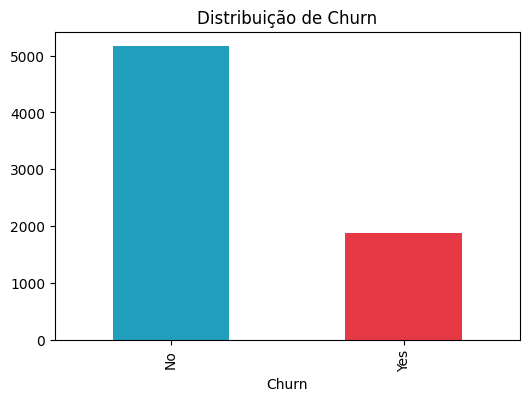

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [8]:
plt.rcParams["figure.figsize"] = (6, 4)
df_original['Churn'].value_counts().plot(kind='bar', color=['#219ebc', '#e63946'], title='Distribuição de Churn')
plt.show()

print(df_original['Churn'].value_counts(normalize=True) * 100)


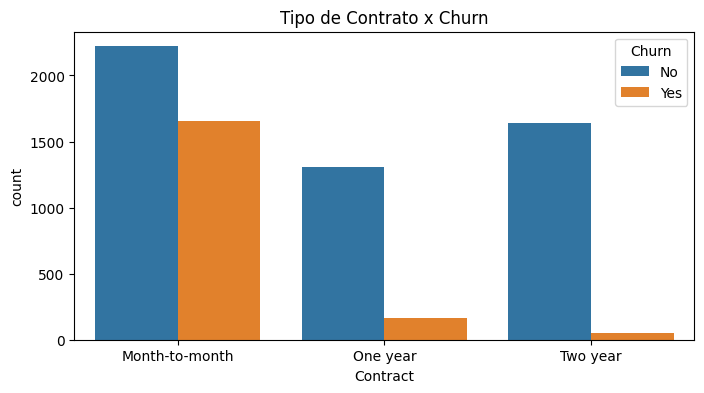

In [9]:
plt.rcParams["figure.figsize"] = [8.00, 4.00]
sns.countplot(data=df_original, x='Contract', hue='Churn')
plt.title('Tipo de Contrato x Churn')
plt.show()


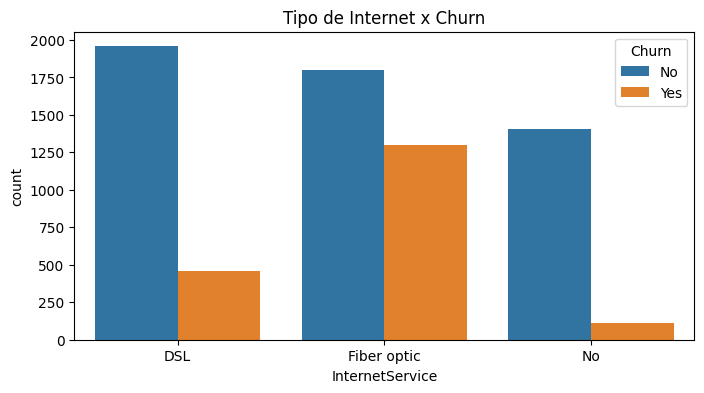

In [10]:
sns.countplot(data=df_original, x='InternetService', hue='Churn')
plt.title('Tipo de Internet x Churn')
plt.show()


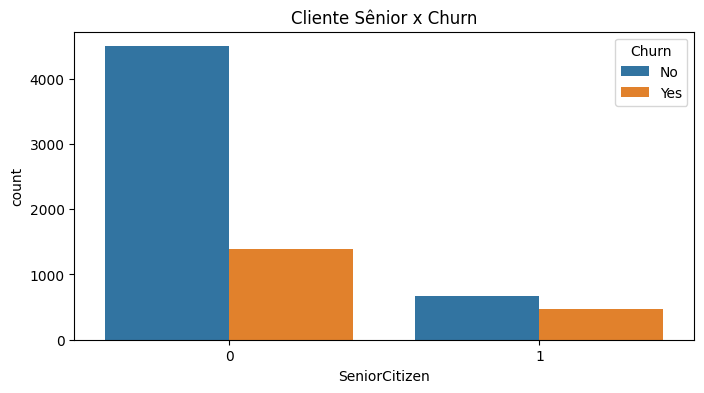

In [11]:
sns.countplot(data=df_original, x='SeniorCitizen', hue='Churn')
plt.title('Cliente Sênior x Churn')
plt.show()


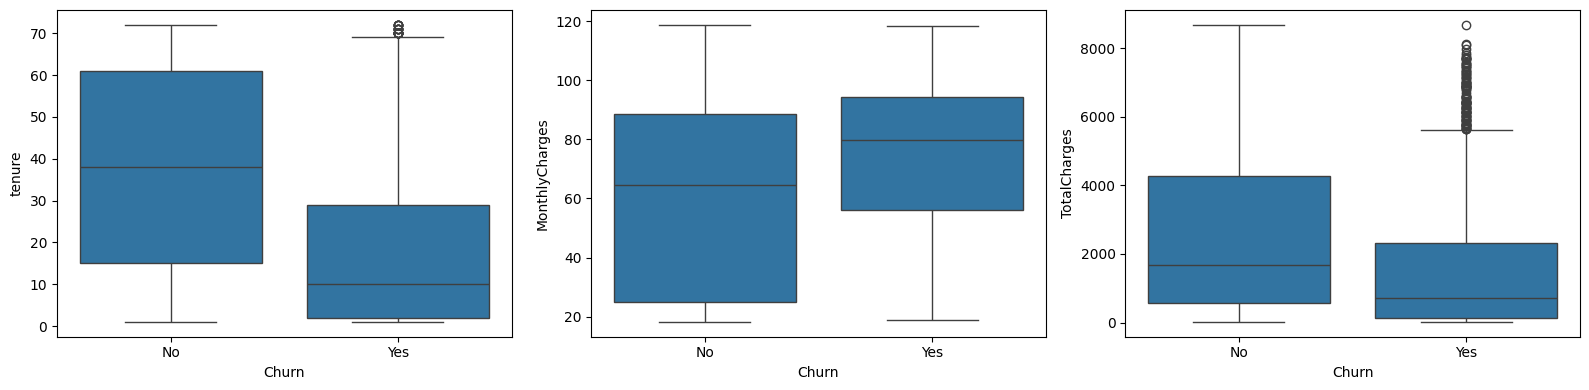

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.boxplot(data=df_original, y='tenure', x='Churn', ax=axes[0])
sns.boxplot(data=df_original, y='MonthlyCharges', x='Churn', ax=axes[1])
sns.boxplot(data=df_original, y='TotalCharges', x='Churn', ax=axes[2])
plt.tight_layout()
plt.show()


## 4. Pré-processamento

Convertendo variáveis categóricas para numéricas com `LabelEncoder`, para que o modelo de Machine Learning consiga processá-las.

In [13]:
variaveis_categoricas = df_original.select_dtypes(include=['object']).columns.tolist()
variaveis_categoricas.remove('Churn')  # o target é tratado separadamente
print(variaveis_categoricas)


['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [14]:
lb = LabelEncoder()
for var in variaveis_categoricas:
    df_original[var] = lb.fit_transform(df_original[var])

# Codificando o target: Yes -> 1 (cancelou), No -> 0 (permaneceu)
df_original['Churn'] = df_original['Churn'].map({'Yes': 1, 'No': 0})

df_original.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [15]:
PREDITORAS = df_original.drop(columns=['Churn'])
TARGET = df_original['Churn']

PREDITORAS.shape, TARGET.shape


((7032, 19), (7032,))

## 5. Balanceamento das classes com SMOTE

In [16]:
print("Distribuição ANTES do balanceamento:")
print(TARGET.value_counts())

seed = 100
balanceador = SMOTE(random_state=seed)
PREDITORAS_RES, TARGET_RES = balanceador.fit_resample(PREDITORAS, TARGET)

print("\nDistribuição DEPOIS do balanceamento:")
print(TARGET_RES.value_counts())


Distribuição ANTES do balanceamento:
Churn
0    5163
1    1869
Name: count, dtype: int64

Distribuição DEPOIS do balanceamento:
Churn
0    5163
1    5163
Name: count, dtype: int64


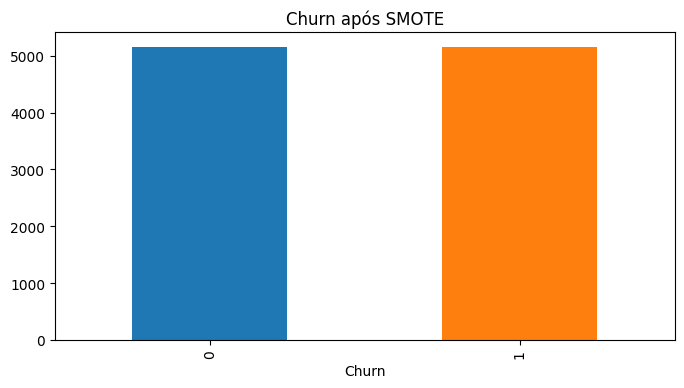

In [17]:
TARGET_RES.value_counts().plot(kind='bar', title='Churn após SMOTE', color=['#1F77B4', '#FF7F0E'])
plt.show()


## 6. Divisão treino/teste e normalização

In [18]:
X_treino, X_teste, Y_treino, Y_teste = train_test_split(
    PREDITORAS_RES, TARGET_RES, test_size=0.3, random_state=42, stratify=TARGET_RES
)

normalizador = MinMaxScaler()
X_treino_norm = normalizador.fit_transform(X_treino)
X_teste_norm = normalizador.transform(X_teste)

X_treino.shape, X_teste.shape


((7228, 19), (3098, 19))

## 7. Treinando o modelo (Random Forest)

In [19]:
clf = RandomForestClassifier(
    n_estimators=300, criterion='entropy', max_depth=10,
    max_features='sqrt', min_samples_leaf=2, min_samples_split=2,
    n_jobs=-1, random_state=42
)
clf.fit(X_treino_norm, Y_treino)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

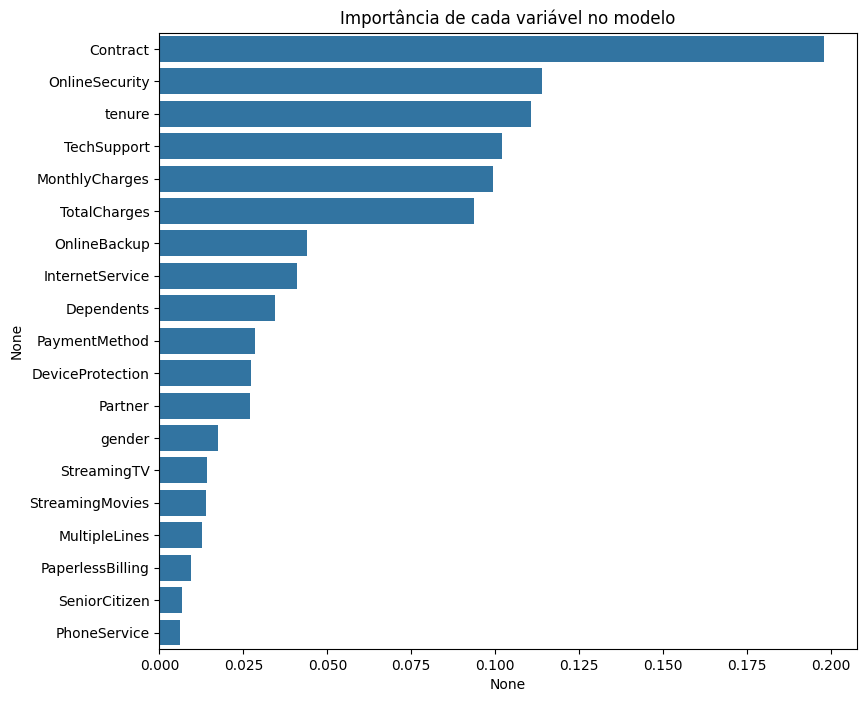

In [20]:
importances = pd.Series(data=clf.feature_importances_, index=PREDITORAS.columns)
importances = importances.sort_values(ascending=False)

plt.rcParams["figure.figsize"] = [9, 8]
sns.barplot(x=importances, y=importances.index, orient='h')
plt.title('Importância de cada variável no modelo')
plt.show()


## 8. Avaliação do modelo

In [21]:
acuracia_treino = clf.score(X_treino_norm, Y_treino)
acuracia_teste = clf.score(X_teste_norm, Y_teste)
print(f"Acurácia em treino: {acuracia_treino*100:.2f}%")
print(f"Acurácia em teste:  {acuracia_teste*100:.2f}%")


Acurácia em treino: 89.18%
Acurácia em teste:  82.60%


In [22]:
y_pred = clf.predict(X_teste_norm)
print(classification_report(Y_teste, y_pred, target_names=['Não Cancelou', 'Cancelou']))


              precision    recall  f1-score   support

Não Cancelou       0.86      0.78      0.82      1549
    Cancelou       0.80      0.87      0.83      1549

    accuracy                           0.83      3098
   macro avg       0.83      0.83      0.83      3098
weighted avg       0.83      0.83      0.83      3098



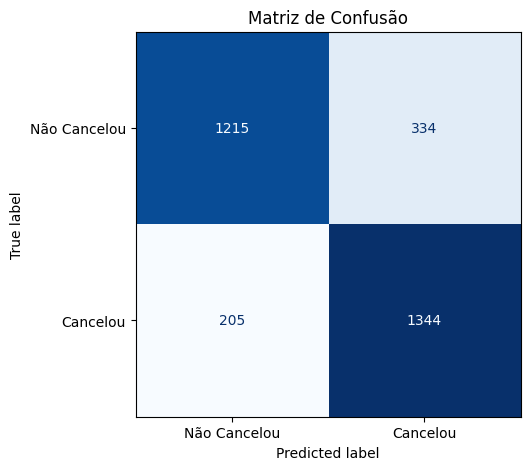

In [23]:
cm = confusion_matrix(Y_teste, y_pred)
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Cancelou', 'Cancelou'])

plt.rcParams["figure.figsize"] = [5, 5]
cm_disp.plot(cmap='Blues', colorbar=False)
plt.title('Matriz de Confusão')
plt.show()


## 9. Conclusões

O dataset tinha **7.043 clientes** (7.032 após remover registros com `TotalCharges` ausente). A proporção original de cancelamento era de **26,58% cancelaram vs. 73,42% permaneceram** — um desbalanceamento relevante, que justificou o uso do SMOTE (que igualou as duas classes em 5.163 registros cada antes da divisão treino/teste).

**Resultados do modelo (Random Forest):**
- Acurácia em treino: **89,18%**
- Acurácia em teste: **82,60%**
- Precisão / Recall / F1 (teste): em torno de **0,83** para ambas as classes, de forma equilibrada — resultado direto de balancear a base antes de treinar, já que sem o SMOTE o modelo tenderia a acertar muito mais a classe majoritária ("não cancelou") e ir mal na classe que realmente importa para o negócio (quem cancela).

**Variáveis mais importantes para prever o cancelamento**, em ordem: `Contract` (tipo de contrato), `OnlineSecurity`, `tenure` (tempo de casa), `TechSupport`, `MonthlyCharges` e `TotalCharges`. Isso confirma a intuição de negócio: clientes com **contrato mensal (sem fidelidade)**, **pouco tempo de casa** e **sem serviços adicionais de segurança/suporte técnico** são os que mais concentram risco de cancelamento — um alvo claro para o time de retenção agir preventivamente (por exemplo, oferecendo desconto para migrar de contrato mensal para anual, ou incluindo suporte técnico gratuito por um período).
